In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
!pip install scikit-optimize
from skopt import BayesSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scipy.stats
import os
!pip install rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
###

#open database:
import pandas as pd
df1=pd.read_excel('')
df2=pd.read_excel('')

df = pd.merge(df1, df2[['record_id', 'age', 'sex', 'education']], on='record_id', how='left')
df.rename(columns={'age_y': 'age','sex_y': 'sex', 'education_y': 'education'}, inplace=True)
df.to_excel('', header=True)

df_ad = df[df['diagnosis'].isin(['CN', 'AD'])]
df_ad.to_excel('df_redlat_final_AD.xlsx', header=True)

df_ftd= df[df['diagnosis'].isin(['CN', 'FTD'])]
df_ftd.to_excel('', header=True)


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving df_redlat_final_29.4.2025.csv to df_redlat_final_29.4.2025.csv


In [ ]:
%%R

# Load R libraries
if (!requireNamespace("MatchIt", quietly = TRUE)) {
    install.packages("MatchIt")
}
if (!requireNamespace("dplyr", quietly = TRUE)) {
    install.packages("dplyr")
}
library(MatchIt)
library(dplyr)

# Load the data
df <- read.csv(" ")

# Print column names for debugging
print(colnames(df))

# Map CN to 0 and AD/FTD to 1 directly
df_filtered <- df %>%
    mutate(diagnosis = ifelse(diagnosis == "CN", 0, 1))  # Map CN to 0 and AD to 1

# Explicitly convert diagnosis to a factor with levels 0 and 1
df_filtered$diagnosis <- factor(df_filtered$diagnosis, levels = c(0, 1))

# Confirm diagnosis has only two levels: 0 and 1
print(levels(df_filtered$diagnosis))  # Should print "0" and "1"

# Remove rows with NA in the columns of interest, keeping patient_id
df_filtered <- na.omit(df_filtered[, c("record_id", "diagnosis", "age", "sex", "education")])  # Adjust as needed

# Perform matching with MatchIt on the binary diagnosis variable
matchit_out <- matchit(diagnosis ~ age + sex + education, data = df_filtered, method = "nearest")

# Extract matched data, including patient_id
matched_df <- match.data(matchit_out)

# Save the matched data to a CSV
write.csv(matched_df, " ", row.names = FALSE)






  [1] "X"                                                          
  [2] "Unnamed..0"                                                 
  [3] "record_id"                                                  
  [4] "site"                                                       
  [5] "Country"                                                    
  [6] "cdr_date"                                                   
  [7] "cdr_examiner"                                               
  [8] "cdr_means"                                                  
  [9] "cdr_memory"                                                 
 [10] "cdr_orient"                                                 
 [11] "cdr_prblm"                                                  
 [12] "cdr_cmnaff"                                                 
 [13] "cdr_hobby"                                                  
 [14] "cdr_care"                                                   
 [15] "cdr_behav"                               

In [ ]:
%%R
summary(matchit_out, un = FALSE)



Call:
matchit(formula = diagnosis ~ age + sex + education, data = df_filtered, 
    method = "nearest")

Summary of Balance for Matched Data:
          Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance         0.4099        0.3868          0.1362     1.2333    0.0267
age             67.3235       66.6667          0.0846     1.0367    0.0214
sex              1.5000        1.4804          0.0390     1.0015    0.0098
education       13.0196       13.4216         -0.0859     1.1280    0.0222
          eCDF Max Std. Pair Dist.
distance    0.1275          0.1418
age         0.0980          0.7059
sex         0.0196          0.6634
education   0.0686          0.9364

Sample Sizes:
          Control Treated
All           226     102
Matched       102     102
Unmatched     124       0
Discarded       0       0



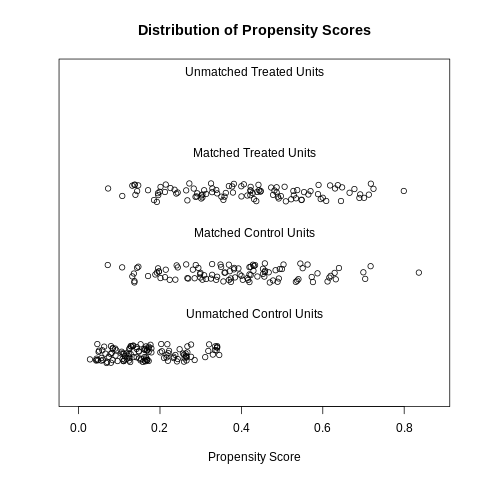

In [ ]:
%%R
plot(matchit_out, type = "jitter", interactive = FALSE)


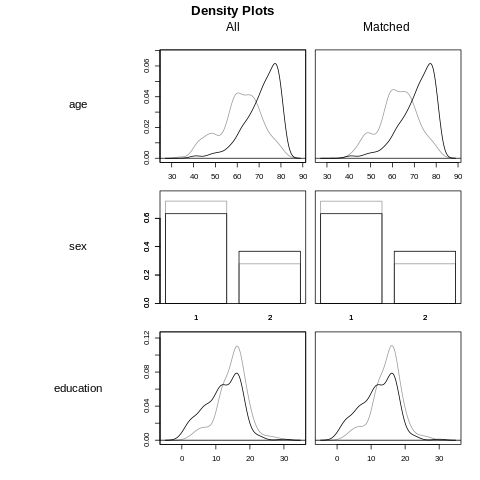

In [ ]:
%%R
plot(matchit_out, type = "density", interactive = FALSE,
     which.xs = ~age + sex + education)

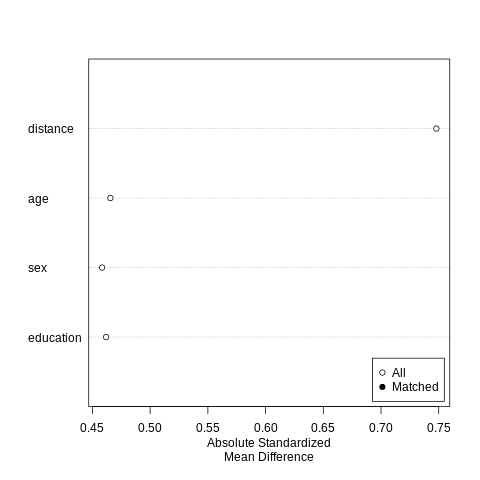

In [ ]:
%%R
plot(summary(matchit_out))

In [ ]:
%%R
m.data <- match.data(matchit_out)

head(m.data)

  record_id diagnosis age sex education  distance weights subclass
1     AF023         0  72   1         6 0.4889343       1       42
2     AF025         0  75   2        16 0.5870243       1       54
3     AF027         0  77   1         6 0.5728181       1       90
4     AF033         0  57   1        16 0.1370319       1       63
7     AF044         1  75   1        12 0.4227492       1       93
9     AF050         1  76   2         9 0.7245828       1       98
